In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
nav = pd.read_csv(
    "../data/processed/cleaned_nav_history.csv"
)

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/processed/cleaned_10_benchmark_indices.csv"
)

print("All datasets loaded successfully")

All datasets loaded successfully


In [5]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav["nav"] = pd.to_numeric(
    nav["nav"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"]
)

print("Data types fixed")

Data types fixed


In [6]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


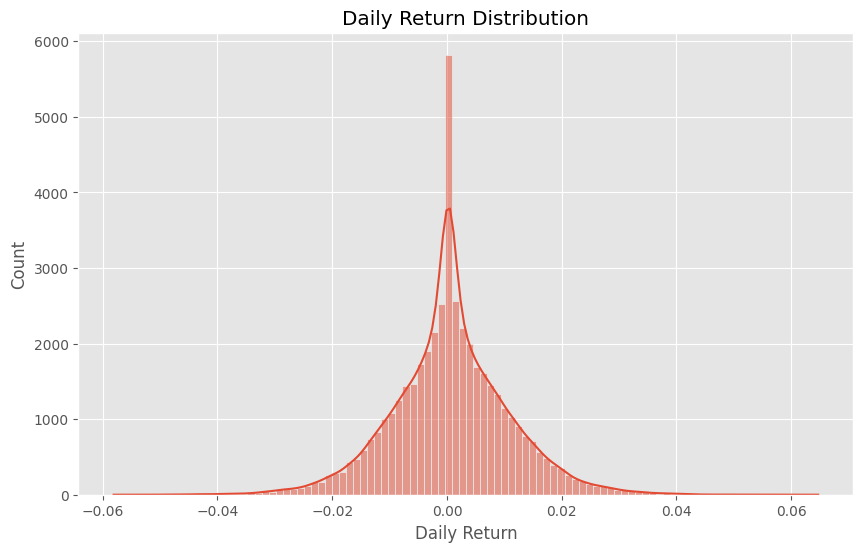

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.show()

### Insight 1:
Daily return distribution appears reasonably centered around zero, indicating normal market volatility patterns.

In [8]:
performance["return_1yr_pct"] = pd.to_numeric(
    performance["return_1yr_pct"]
)

performance["return_3yr_pct"] = pd.to_numeric(
    performance["return_3yr_pct"]
)

performance["return_5yr_pct"] = pd.to_numeric(
    performance["return_5yr_pct"]
)

cagr_table = performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

cagr_table.columns = [
    "Scheme Name",
    "1 Year CAGR (%)",
    "3 Year CAGR (%)",
    "5 Year CAGR (%)"
]

print(cagr_table.head())

                                    Scheme Name  1 Year CAGR (%)  \
0     SBI Bluechip Fund - Regular Plan - Growth            12.42   
1      SBI Bluechip Fund - Direct Plan - Growth            15.25   
2    SBI Small Cap Fund - Regular Plan - Growth            24.56   
3     SBI Small Cap Fund - Direct Plan - Growth            20.59   
4  SBI Magnum Gilt Fund - Regular Plan - Growth             5.34   

   3 Year CAGR (%)  5 Year CAGR (%)  
0            12.36            14.45  
1            11.30            14.23  
2            23.39            20.67  
3            23.14            21.82  
4             6.07             5.43  


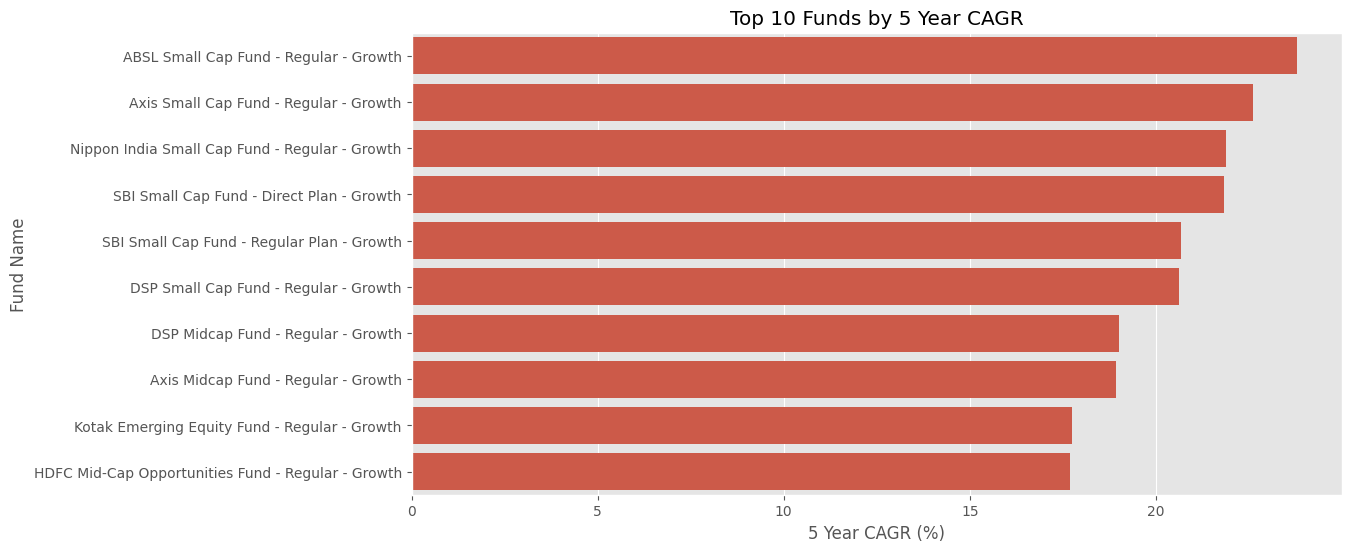

In [9]:
top_funds = cagr_table.sort_values(
    by="5 Year CAGR (%)",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="5 Year CAGR (%)",
    y="Scheme Name"
)

plt.title("Top 10 Funds by 5 Year CAGR")

plt.xlabel("5 Year CAGR (%)")

plt.ylabel("Fund Name")

plt.show()

### Insight 2:
Funds with higher long-term CAGR demonstrate stronger consistency in wealth creation over a 5-year period.

In [10]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    returns = (
        fund_data["daily_return"]
        .dropna()
    )

    if len(returns) > 0:

        mean_return = (
            returns.mean() * 252
        )

        std_return = (
            returns.std() * np.sqrt(252)
        )

        sharpe_ratio = (
            (mean_return - risk_free_rate)
            / std_return
        )

        sharpe_results.append(
            [fund, sharpe_ratio]
        )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

print(sharpe_df.head())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


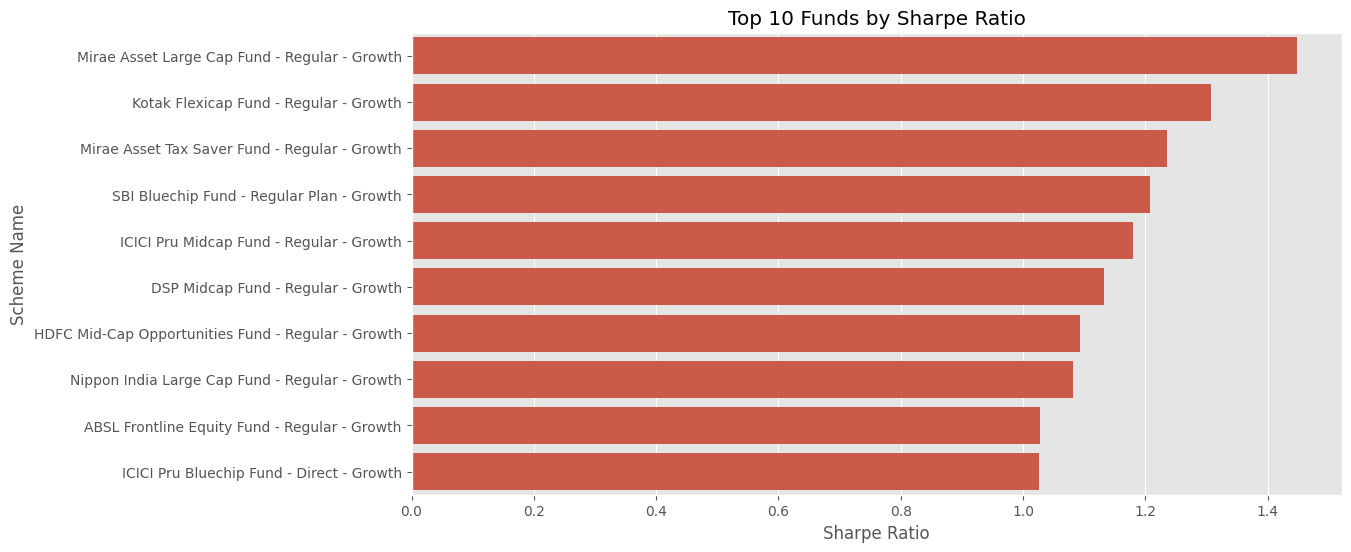

In [11]:
sharpe_df = sharpe_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_sharpe = (
    sharpe_df
    .sort_values(
        by="sharpe_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme Name")

plt.show()

### Insight 3:
Funds with higher Sharpe ratios delivered better risk-adjusted returns, indicating efficient performance relative to volatility.

In [12]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    returns = (
        fund_data["daily_return"]
        .dropna()
    )

    downside_returns = returns[
        returns < 0
    ]

    if len(downside_returns) > 0:

        mean_return = (
            returns.mean() * 252
        )

        downside_std = (
            downside_returns.std()
            * np.sqrt(252)
        )

        sortino_ratio = (
            (mean_return - risk_free_rate)
            / downside_std
        )

        sortino_results.append(
            [fund, sortino_ratio]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


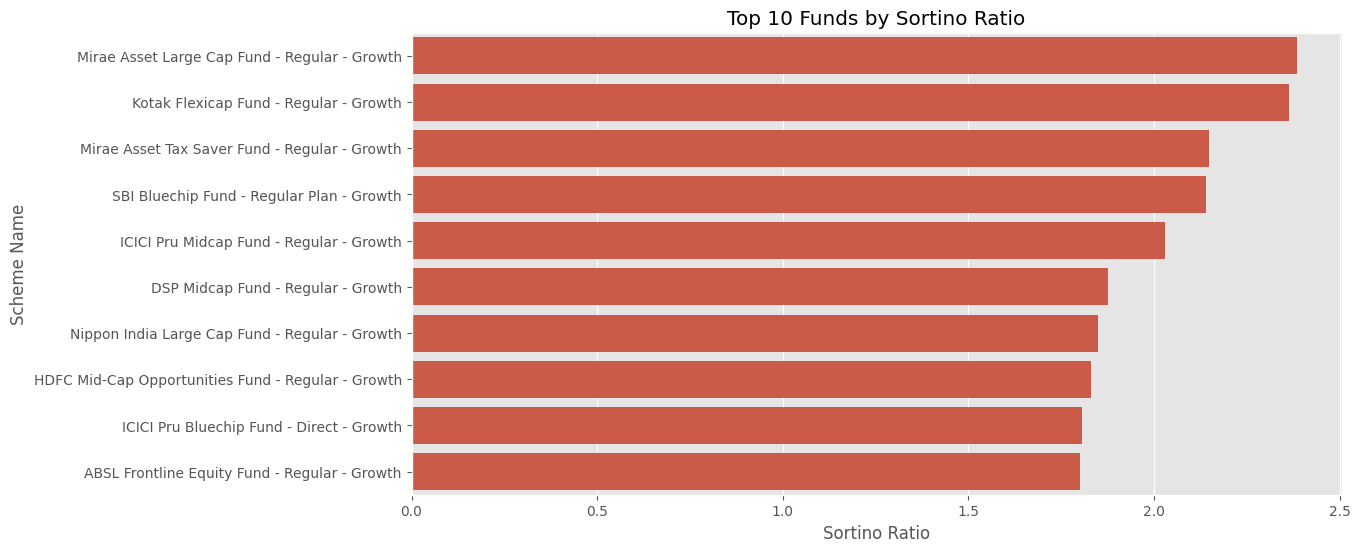

In [13]:
sortino_df = sortino_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_sortino = (
    sortino_df
    .sort_values(
        by="sortino_ratio",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.show()

### Insight 4:
Funds with stronger Sortino ratios managed downside risk efficiently while still generating strong returns.

In [14]:
print(
    benchmark["index_name"]
    .unique()
)

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [15]:
# Filter NIFTY100

nifty100 = benchmark[
    benchmark["index_name"]
    == "NIFTY100"
].copy()

# Sort values

nifty100 = nifty100.sort_values(
    "date"
)

# Daily benchmark returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [16]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][
        ["date", "daily_return"]
    ]

    merged = fund_data.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        alpha = (
            regression.intercept
            * 252
        )

        alpha_beta_results.append([
            fund,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [17]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [18]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values(
        "date"
    )

    fund_data["running_max"] = (
        fund_data["nav"]
        .cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        /
        fund_data["running_max"]
        - 1
    )

    max_drawdown = (
        fund_data["drawdown"]
        .min()
    )

    drawdown_results.append([
        fund,
        max_drawdown
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

print(drawdown_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


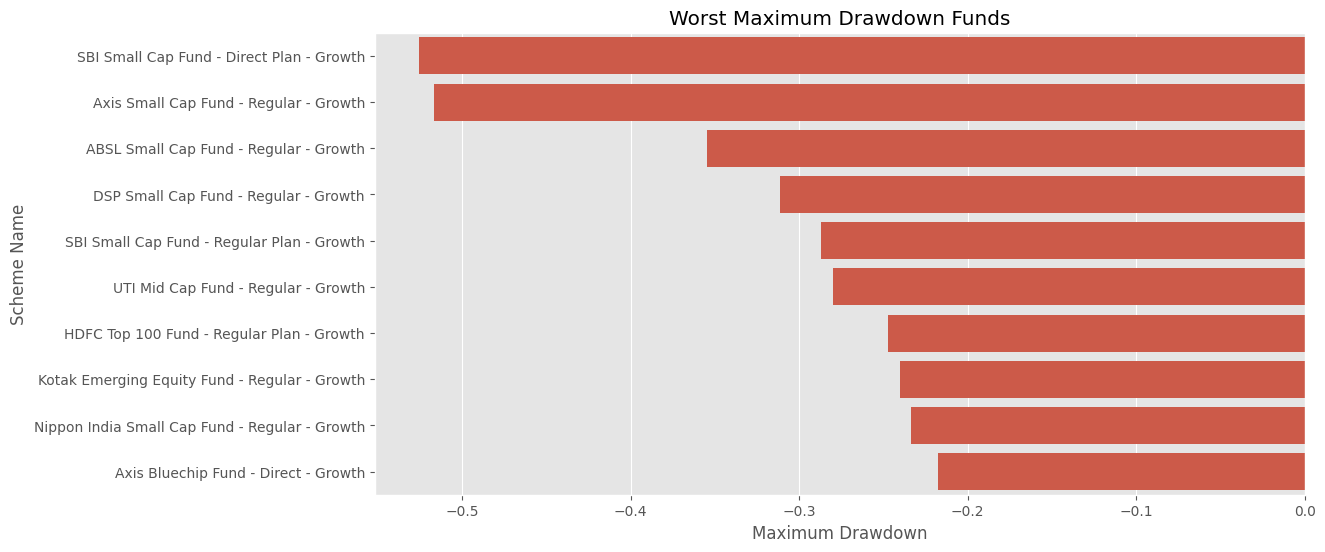

In [19]:
drawdown_df = drawdown_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

worst_drawdown = (
    drawdown_df
    .sort_values(
        by="max_drawdown"
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_drawdown,
    x="max_drawdown",
    y="scheme_name"
)

plt.title(
    "Worst Maximum Drawdown Funds"
)

plt.xlabel(
    "Maximum Drawdown"
)

plt.ylabel(
    "Scheme Name"
)

plt.show()

### Insight 6:
Funds with deeper maximum drawdowns experienced higher downside risk during market corrections.

In [20]:
scorecard = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard["return_3yr_pct"] = pd.to_numeric(
    scorecard["return_3yr_pct"]
)

scorecard["expense_ratio_pct"] = pd.to_numeric(
    scorecard["expense_ratio_pct"]
)

In [21]:
scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code",
    how="left"
)

print(scorecard.head())

   amfi_code                                   scheme_name  return_3yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.36   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           11.30   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           23.39   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           23.14   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            6.07   

   expense_ratio_pct  sharpe_ratio     alpha  max_drawdown  
0               1.54      1.208267  0.232010     -0.150124  
1               0.66      0.953279  0.198686     -0.118035  
2               1.43      0.945308  0.303370     -0.287060  
3               0.72     -0.057187  0.048824     -0.525742  
4               0.77     -0.226575  0.056209     -0.043287  


In [22]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

print("Ranking completed")

Ranking completed


In [23]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

top_funds = (
    scorecard
    .sort_values(
        by="fund_score",
        ascending=False
    )
)

print(
    top_funds[
        [
            "scheme_name",
            "fund_score"
        ]
    ].head(10)
)

                                          scheme_name  fund_score
2          SBI Small Cap Fund - Regular Plan - Growth       83.38
12           ICICI Pru Midcap Fund - Regular - Growth       82.25
39              DSP Small Cap Fund - Regular - Growth       77.94
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...       76.00
22             Kotak Flexicap Fund - Regular - Growth       75.25
26                Axis Midcap Fund - Regular - Growth       70.25
38                 DSP Midcap Fund - Regular - Growth       69.00
34      Mirae Asset Large Cap Fund - Regular - Growth       68.75
11          ICICI Pru Bluechip Fund - Direct - Growth       63.00
36      Mirae Asset Tax Saver Fund - Regular - Growth       62.69


In [24]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print(
    "fund_scorecard.csv saved"
)

fund_scorecard.csv saved


### Insight 7:
Funds with consistently strong returns, lower drawdowns, and better risk-adjusted performance achieved the highest composite scores.

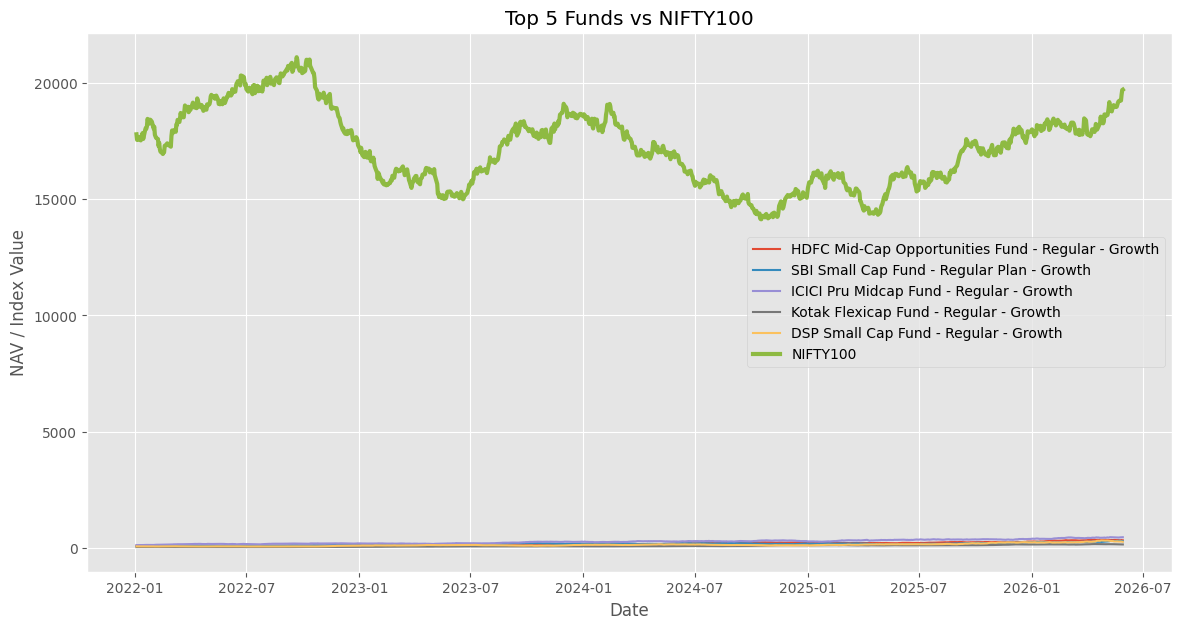

In [25]:
top5_codes = (
    top_funds["amfi_code"]
    .head(5)
    .tolist()
)

top5_nav = nav[
    nav["amfi_code"]
    .isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(14,7))

for scheme in (
    top5_nav["scheme_name"]
    .unique()
):

    temp = top5_nav[
        top5_nav["scheme_name"]
        == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

# Add benchmark

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY100"
)

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.show()

In [26]:
tracking_error_results = []

for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"]
        == fund
    ][
        ["date", "daily_return"]
    ]

    merged = fund_data.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

print(tracking_error_df)

   amfi_code  tracking_error
0     119598        0.283881
1     120505        0.231968
2     149324        0.279170
3     100033        0.228699
4     120843        0.206425


### Insight 8:
Top-performing funds displayed varying levels of tracking error, reflecting differences in benchmark alignment and active management strategy.

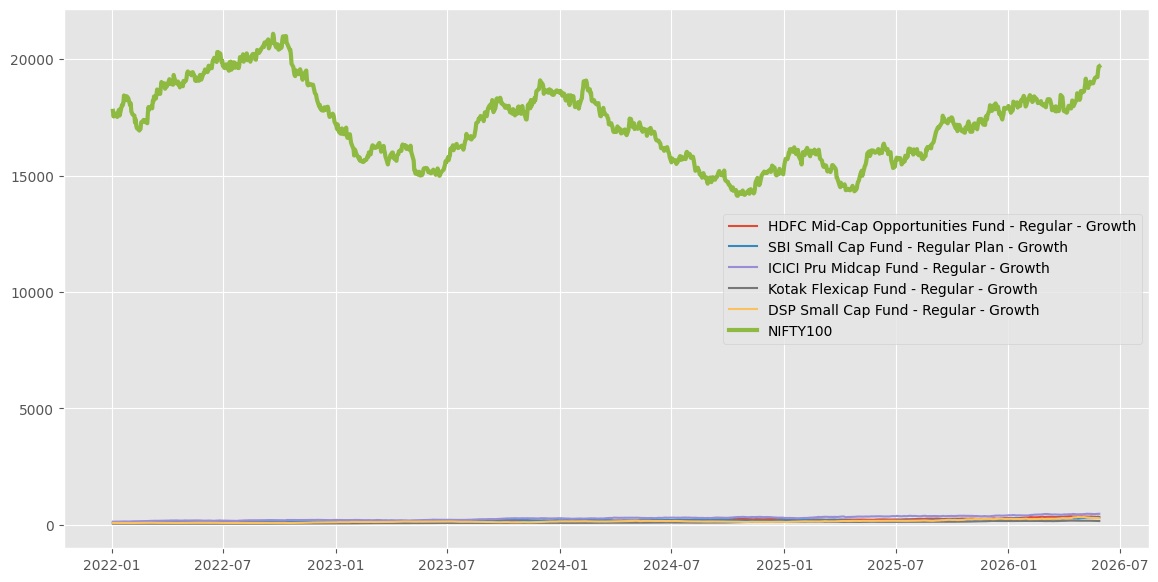

benchmark_comparison.png saved


In [27]:
plt.figure(figsize=(14,7))

for scheme in (
    top5_nav["scheme_name"]
    .unique()
):

    temp = top5_nav[
        top5_nav["scheme_name"]
        == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

print(
    "benchmark_comparison.png saved"
)